<a href="https://colab.research.google.com/github/Thiyaanes/GIT/blob/main/energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
dataset_path = "machine_energy.csv"   # replace with your dataset path
df = pd.read_csv(dataset_path)

print("Columns in dataset:", df.columns.tolist())
print(df.head())


Columns in dataset: ['Timestamp', 'Machine_Type', 'Operation_Type', 'Cycle_Time', 'Energy_Consumed']
             Timestamp Machine_Type Operation_Type  Cycle_Time  \
0  2024-01-01 00:00:00   SMT_Line_1      Soldering          10   
1  2024-01-01 00:00:00   SMT_Line_2      Soldering          14   
2  2024-01-01 00:00:00   CNC_Mill_1        Milling          23   
3  2024-01-01 00:00:00   CNC_Mill_2        Milling          24   
4  2024-01-01 01:00:00   SMT_Line_1       Assembly          12   

   Energy_Consumed  
0             2.60  
1             2.27  
2             3.64  
3             3.30  
4             1.92  


In [ ]:
label_encoders = {}
for col in ["Machine_Type", "Operation_Type"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Select features and target
features = ["Machine_Type", "Operation_Type", "Cycle_Time"]
target = "Energy_Consumed"

X_data = df[features].values
y_data = df[target].values.reshape(-1, 1)

# Scale features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

In [ ]:
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 10  # you can change this (e.g., 24, 48)
X, y = create_sequences(X_scaled, y_scaled, seq_length)


In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(seq_length, len(features))))
model.add(Dropout(0.2))
model.add(Dense(1))  # predicting Energy_Consumed
model.compile(optimizer='adam', loss='mse')

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0709 - val_loss: 0.0403
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0409 - val_loss: 0.0319
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0308 - val_loss: 0.0282
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0285 - val_loss: 0.0278
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0287 - val_loss: 0.0272
Epoch 6/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0277 - val_loss: 0.0270
Epoch 7/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0281 - val_loss: 0.0273
Epoch 8/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0287 - val_loss: 0.0278
Epoch 9/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0276 - val_loss: 0.0268
Epoch 10/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0274 - val_loss: 0.0268
Epoch 11/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0271 - val_loss: 0.0275
Epoch 12/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss

In [ ]:
y_pred = model.predict(X_test)

# Inverse transform predictions and actual
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


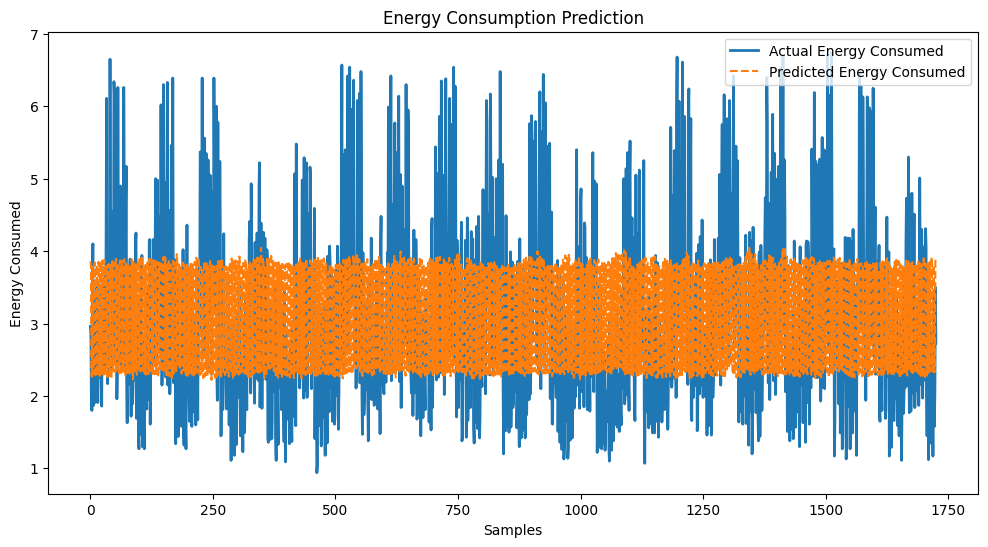

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual Energy Consumed", linewidth=2)
plt.plot(y_pred_inv, label="Predicted Energy Consumed", linestyle="dashed")
plt.title("Energy Consumption Prediction")
plt.xlabel("Samples")
plt.ylabel("Energy Consumed")
plt.legend()
plt.show()

In [ ]:
n_future = 5  # number of future steps to predict

last_seq = X_scaled[-seq_length:]
future_preds = []

current_seq = last_seq.reshape(1, seq_length, len(features))

for _ in range(n_future):
    next_pred = model.predict(current_seq)[0]
    future_preds.append(next_pred)

    # Take last feature row (Machine, Operation, Cycle), keep same values
    new_step = current_seq[:, -1, :].copy()

    # Replace only Energy_Consumed with prediction
    # (energy is not in features here, so we keep features same)
    new_step = np.expand_dims(new_step, axis=1)

    # Append into rolling sequence
    current_seq = np.append(current_seq[:, 1:, :], new_step, axis=1)

# Inverse transform predictions
future_preds_inv = scaler_y.inverse_transform(np.array(future_preds).reshape(-1,1))

print("Future Energy Consumption Predictions:")
print(future_preds_inv.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Future Energy Consumption Predictions:
[2.332354  2.3371203 3.4509559 3.3337967 2.3002582]


In [ ]:
n_future = 5  # number of future steps to predict

# Get last sequence
last_seq = X_scaled[-seq_length:]
future_preds = []

# Keep original categorical + cycle time values from last rows
last_rows = df.tail(seq_length).copy()

current_seq = last_seq.reshape(1, seq_length, len(features))

# Start forecasting
for i in range(n_future):
    next_pred = model.predict(current_seq)[0]
    future_preds.append(next_pred)

    # Take last feature values (machine, operation, cycle_time)
    new_step = current_seq[:, -1, :].copy()
    new_step = np.expand_dims(new_step, axis=1)

    # Update sequence (sliding window)
    current_seq = np.append(current_seq[:, 1:, :], new_step, axis=1)

# Inverse transform predictions
future_preds_inv = scaler_y.inverse_transform(np.array(future_preds).reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [ ]:
# ----------------------------
# Future Forecast Table (Safe Version)
# ----------------------------

# Use last timestamp and generate future timestamps
last_timestamp = pd.to_datetime(df["Timestamp"].iloc[-1])
future_timestamps = [last_timestamp + pd.Timedelta(hours=i+1) for i in range(n_future)]

# Get last known Machine/Operation/CycleTime
machine_val = df["Machine_Type"].iloc[-1]  # string, e.g., 'CNC_Mill_2'
operation_val = df["Operation_Type"].iloc[-1]  # string, e.g., 'Soldering'
cycle_val = df["Cycle_Time"].iloc[-1]

# ----------------------------
# Create forecast dataframe directly using strings
# ----------------------------
forecast_df = pd.DataFrame({
    "Timestamp": future_timestamps,
    "Machine_Type": [machine_val] * n_future,
    "Operation_Type": [operation_val] * n_future,
    "Cycle_Time": [cycle_val] * n_future,
    "Predicted_Energy": future_preds_inv.flatten()
})

print("\nFuture Forecast Table:")
print(forecast_df)




Future Forecast Table:
            Timestamp Machine_Type Operation_Type  Cycle_Time  \
0 2024-03-31 00:00:00   CNC_Mill_2       Drilling          10   
1 2024-03-31 01:00:00   CNC_Mill_2       Drilling          10   
2 2024-03-31 02:00:00   CNC_Mill_2       Drilling          10   
3 2024-03-31 03:00:00   CNC_Mill_2       Drilling          10   
4 2024-03-31 04:00:00   CNC_Mill_2       Drilling          10   

   Predicted_Energy  
0          2.332354  
1          2.337120  
2          3.450956  
3          3.333797  
4          2.300258  


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, f1_score

In [ ]:
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("Regression Test Results:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Regression Test Results:
MAE: 0.75
MSE: 0.91
RMSE: 0.95
R² Score: 0.38


In [ ]:
threshold = np.median(y_test_inv)

# Convert actual and predicted to binary classes
y_test_class = (y_test_inv.flatten() > threshold).astype(int)
y_pred_class = (y_pred_inv.flatten() > threshold).astype(int)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)

print("\nClassification Metrics (High/Low Energy):")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"F1 Score: {f1:.2f}")


Classification Metrics (High/Low Energy):
Accuracy: 0.79
Precision: 0.79
F1 Score: 0.79


In [ ]:
print("\nFuture Energy Consumption Predictions:")
print(future_preds_inv.flatten())

# Optional: convert future predictions to high/low energy
future_class = (future_preds_inv.flatten() > threshold).astype(int)
print("Future Predictions (High=1 / Low=0):")
print(future_class)


Future Energy Consumption Predictions:
[2.332354  2.3371203 3.4509559 3.3337967 2.3002582]
Future Predictions (High=1 / Low=0):
[0 0 1 1 0]


In [ ]:
import matplotlib.pyplot as plt


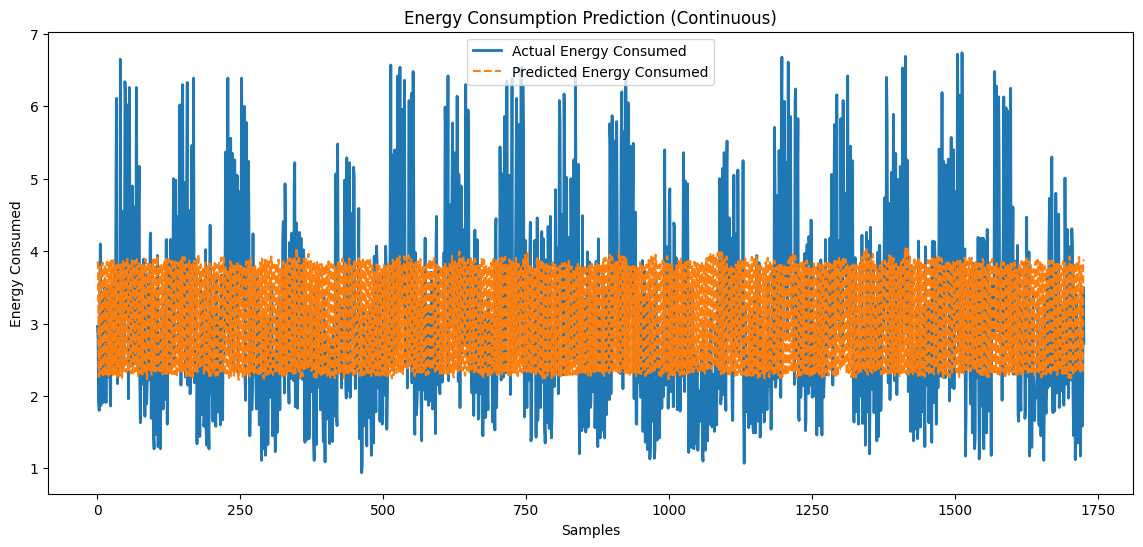

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test_inv, label="Actual Energy Consumed", linewidth=2)
plt.plot(y_pred_inv, label="Predicted Energy Consumed", linestyle="dashed")
plt.title("Energy Consumption Prediction (Continuous)")
plt.xlabel("Samples")
plt.ylabel("Energy Consumed")
plt.legend()
plt.show()

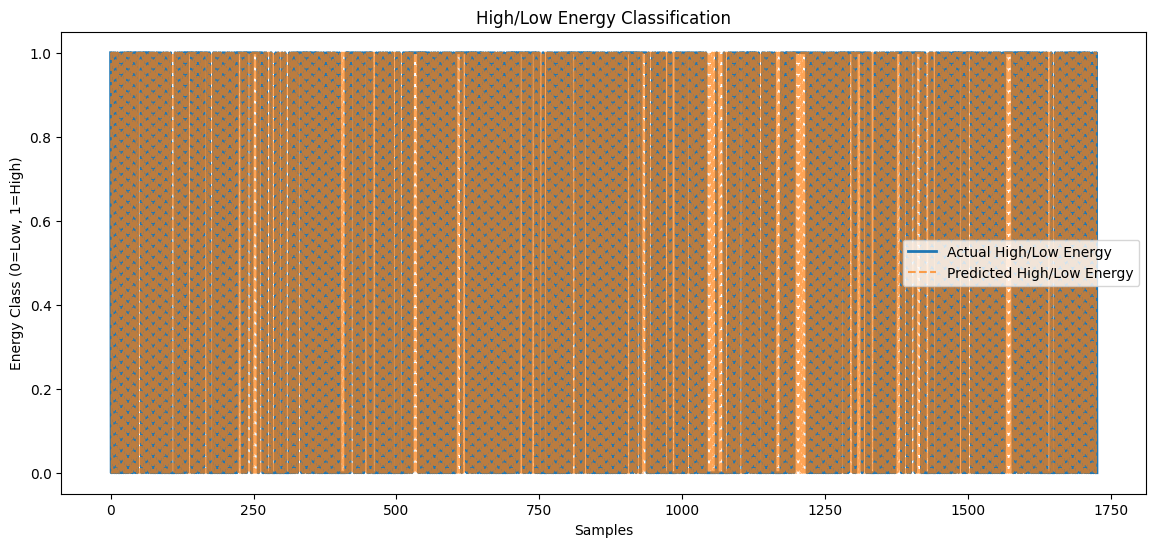

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test_class, label="Actual High/Low Energy", linewidth=2)
plt.plot(y_pred_class, label="Predicted High/Low Energy", linestyle="dashed", alpha=0.7)
plt.title("High/Low Energy Classification")
plt.xlabel("Samples")
plt.ylabel("Energy Class (0=Low, 1=High)")
plt.legend()
plt.show()

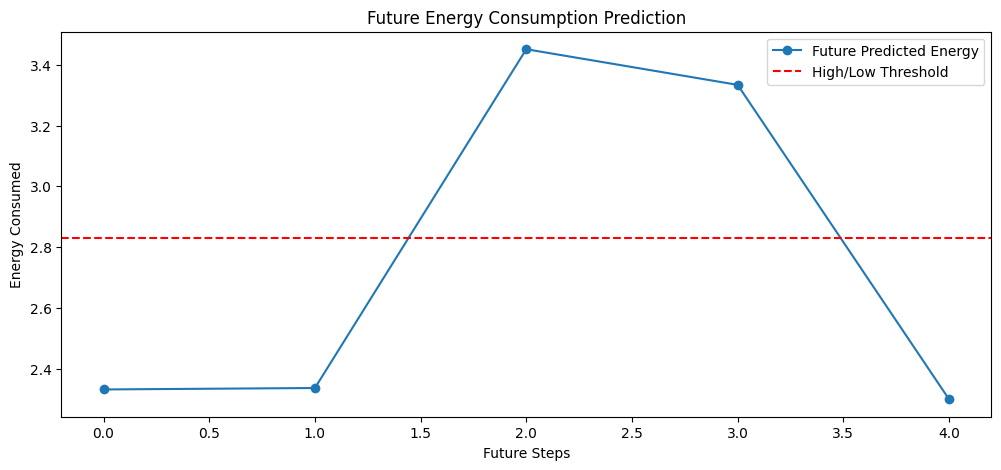

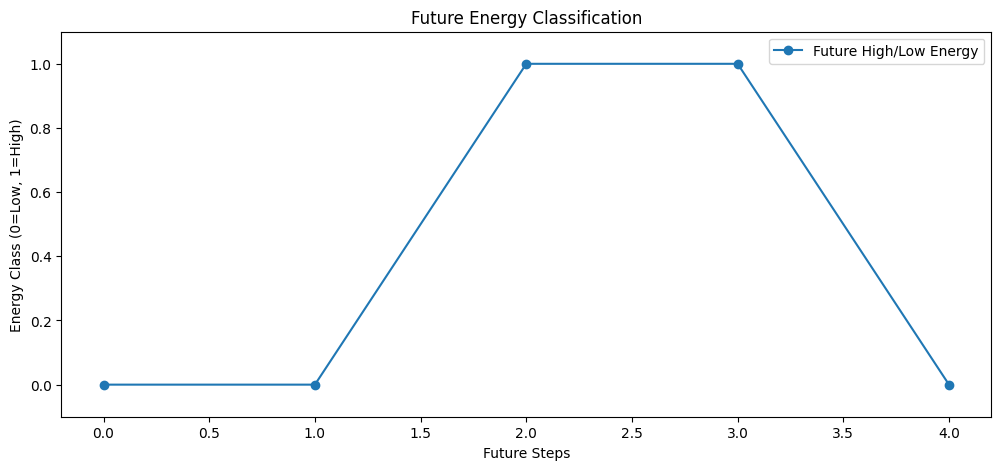

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(future_preds_inv, marker='o', label="Future Predicted Energy")
plt.axhline(y=threshold, color='r', linestyle='--', label="High/Low Threshold")
plt.title("Future Energy Consumption Prediction")
plt.xlabel("Future Steps")
plt.ylabel("Energy Consumed")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(future_class, marker='o', label="Future High/Low Energy")
plt.title("Future Energy Classification")
plt.xlabel("Future Steps")
plt.ylabel("Energy Class (0=Low, 1=High)")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()


In [ ]:
# Define threshold for high energy
threshold = np.median(y_test_inv)

# Compare predicted energy with threshold and suggest optimization
optimization_suggestions = []

for i, energy in enumerate(future_preds_inv.flatten()):
    if energy > threshold:
        suggestion = f"machine {i+1}: High energy predicted ({energy:.2f}). Suggest reducing cycle time or rescheduling operation."
    else:
        suggestion = f"machine {i+1}: Energy normal ({energy:.2f}). No action needed."
    optimization_suggestions.append(suggestion)

print("\nEnergy Optimization Suggestions:")
for s in optimization_suggestions:
    print(s)



Energy Optimization Suggestions:
machine 1: Energy normal (2.33). No action needed.
machine 2: Energy normal (2.34). No action needed.
machine 3: High energy predicted (3.45). Suggest reducing cycle time or rescheduling operation.
machine 4: High energy predicted (3.33). Suggest reducing cycle time or rescheduling operation.
machine 5: Energy normal (2.30). No action needed.


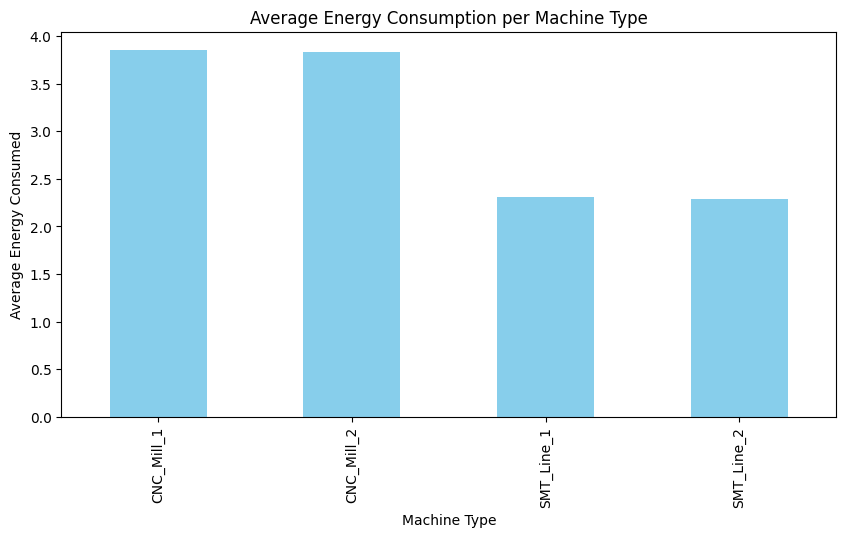

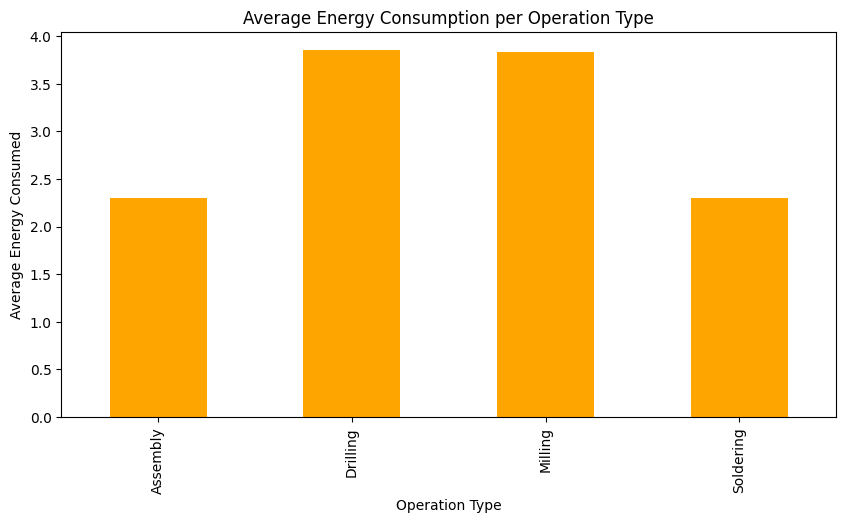

In [ ]:
# Average energy per Machine_Type
avg_energy_machine = df.groupby('Machine_Type')['Energy_Consumed'].mean()
avg_energy_operation = df.groupby('Operation_Type')['Energy_Consumed'].mean()

# Plot per Machine_Type
plt.figure(figsize=(10,5))
avg_energy_machine.plot(kind='bar', color='skyblue')
plt.title("Average Energy Consumption per Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Average Energy Consumed")
plt.show()

# Plot per Operation_Type
plt.figure(figsize=(10,5))
avg_energy_operation.plot(kind='bar', color='orange')
plt.title("Average Energy Consumption per Operation Type")
plt.xlabel("Operation Type")
plt.ylabel("Average Energy Consumed")
plt.show()
